In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import SVG, display
from scipy import stats

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'data').is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
MATRIX_DIR = PROJECT_DIR / 'data'
if not (MATRIX_DIR / 'fastani-upper-triangle.parquet').is_file():
    MATRIX_DIR = PROJECT_DIR.parents[1] / PROJECT_DIR.name / 'data'

ANI_PATH = MATRIX_DIR / 'fastani-upper-triangle.parquet'
AF_PATH = MATRIX_DIR / 'fastani-AF-upper-triangle.parquet'
LCA_PATH = MATRIX_DIR / 'LCA.parquet'
METADATA_PATH = PROJECT_DIR / 'assets' / 'genome_tax_metadata.parquet'
ENTERO_PATH = PROJECT_DIR / 'data' / 'enterobacteriaceae_fastani.parquet'
for required_path in (ANI_PATH, AF_PATH, LCA_PATH, METADATA_PATH, ENTERO_PATH):
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

FIGS_DIR = PROJECT_DIR / 'assets' / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_SVG = FIGS_DIR / 'supplemental1.svg'
FIGURE_PDF = FIGS_DIR / 'supplemental1.pdf'
FIGURE_PNG = FIGS_DIR / 'supplemental1.png'

ANI_MIN, ANI_MAX = 80.0, 100.0
ANI_BIN_CENTERS = np.arange(80, 101, dtype=float)
ANI_BIN_EDGES = np.arange(79.5, 101.0, 1.0)
BOOTSTRAP_REPLICATES = 10_000
RANDOM_SEED = 42

PUBLICATION_FONT = 'Nimbus Sans'
PLOT_STYLE = {
    'font.family': 'sans-serif',
    'font.sans-serif': [PUBLICATION_FONT, 'Arial', 'Helvetica', 'DejaVu Sans'],
    'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.unicode_minus': False,
}
plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style='whitegrid', font=PUBLICATION_FONT, rc=PLOT_STYLE)

def sql_path(path):
    return str(path).replace("'", "''")

In [2]:
con = duckdb.connect()
con.execute('SET threads=4')
con.execute('SET max_expression_depth=100000')
euk = con.execute(
    f"""
    WITH ani_long AS (
        SELECT assembly_accession AS genome1, compared_accession AS genome2, v::DOUBLE AS ANI
        FROM (UNPIVOT read_parquet('{sql_path(ANI_PATH)}')
              ON COLUMNS(* EXCLUDE (assembly_accession))
              INTO NAME compared_accession VALUE v)
        WHERE assembly_accession <> compared_accession AND v IS NOT NULL AND isfinite(v::DOUBLE)
    ),
    af_long AS (
        SELECT assembly_accession AS genome1, compared_accession AS genome2, v::DOUBLE AS AF
        FROM (UNPIVOT read_parquet('{sql_path(AF_PATH)}')
              ON COLUMNS(* EXCLUDE (assembly_accession))
              INTO NAME compared_accession VALUE v)
        WHERE assembly_accession <> compared_accession AND v IS NOT NULL AND isfinite(v::DOUBLE)
    ),
    lca_long AS (
        SELECT assembly_accession AS genome1, compared_accession AS genome2, v AS LCA
        FROM (UNPIVOT read_parquet('{sql_path(LCA_PATH)}')
              ON COLUMNS(* EXCLUDE (assembly_accession))
              INTO NAME compared_accession VALUE v)
        WHERE assembly_accession <> compared_accession AND v IS NOT NULL
    ),
    retained AS (
        SELECT ncbi_genome_accession AS genome, family_2026_09_01 AS family_name
        FROM read_parquet('{sql_path(METADATA_PATH)}')
        WHERE qc = 'pass'
    )
    SELECT a.genome1, a.genome2, a.ANI, 100.0 * f.AF AS AF_pct, l.LCA, m1.family_name
    FROM ani_long a
    JOIN af_long f USING (genome1, genome2)
    JOIN lca_long l USING (genome1, genome2)
    JOIN retained m1 ON a.genome1 = m1.genome
    JOIN retained m2 ON a.genome2 = m2.genome
    WHERE l.LCA IN ('species', 'genus', 'family')
      AND m1.family_name IS NOT NULL
      AND m1.family_name = m2.family_name
      AND a.ANI BETWEEN {ANI_MIN} AND {ANI_MAX}
      AND f.AF BETWEEN 0 AND 1
    """
).fetchdf()

entero = con.execute(
    f"""
    WITH directed AS (
        SELECT
            least(query_accession, reference_accession) AS genome1,
            greatest(query_accession, reference_accession) AS genome2,
            ANI::DOUBLE AS ANI, AF::DOUBLE AS AF
        FROM read_parquet('{sql_path(ENTERO_PATH)}')
        WHERE query_accession <> reference_accession
          AND ANI IS NOT NULL AND isfinite(ANI::DOUBLE)
          AND AF IS NOT NULL AND isfinite(AF::DOUBLE)
    )
    SELECT genome1, genome2, avg(ANI) AS ANI, 100.0 * avg(AF) AS AF_pct
    FROM directed
    GROUP BY genome1, genome2
    HAVING avg(ANI) BETWEEN {ANI_MIN} AND {ANI_MAX}
       AND avg(AF) BETWEEN 0 AND 1
    """
).fetchdf()
con.close()

print(f'Within-family eukaryote pairs: {len(euk):,}')
print(f'Unique Enterobacteriaceae pairs: {len(entero):,}')
print(f'Eukaryotic families represented: {euk.family_name.nunique():,}')

Within-family eukaryote pairs: 2,154,142
Unique Enterobacteriaceae pairs: 494,022
Eukaryotic families represented: 31


In [3]:
def assign_ani_bins(frame):
    out = frame.copy()
    out['ANI_bin'] = pd.cut(
        out['ANI'], bins=ANI_BIN_EDGES, labels=ANI_BIN_CENTERS, include_lowest=True,
    ).astype(float)
    return out.dropna(subset=['ANI_bin'])


euk_binned_rows = assign_ani_bins(euk)
entero_binned_rows = assign_ani_bins(entero)
entero_curve = (
    entero_binned_rows.groupby('ANI_bin', observed=True)
    .agg(AF_median=('AF_pct', 'median'), comparisons=('AF_pct', 'size'))
    .reset_index()
)
euk_pooled_curve = (
    euk_binned_rows.groupby('ANI_bin', observed=True)
    .agg(AF_median=('AF_pct', 'median'), comparisons=('AF_pct', 'size'))
    .reset_index()
)
def matched_bin_statistics(euk_curve, entero_curve):
    matched = entero_curve[['ANI_bin', 'AF_median']].merge(
        euk_curve[['ANI_bin', 'AF_median']], on='ANI_bin', suffixes=('_enterobacteriaceae', '_eukaryote'),
    )
    matched['delta_AF'] = matched['AF_median_eukaryote'] - matched['AF_median_enterobacteriaceae']
    delta = matched['delta_AF'].to_numpy()
    rng = np.random.default_rng(RANDOM_SEED)
    boot = np.array([np.median(rng.choice(delta, size=len(delta), replace=True)) for _ in range(BOOTSTRAP_REPLICATES)])
    wilcoxon = stats.wilcoxon(
        matched['AF_median_eukaryote'], matched['AF_median_enterobacteriaceae'],
    )
    return {
        'matched': matched, 'median_delta': float(np.median(delta)),
        'ci_low': float(np.quantile(boot, 0.025)), 'ci_high': float(np.quantile(boot, 0.975)),
        'p_value': float(wilcoxon.pvalue), 'n_bins': len(delta),
    }


pooled_stats = matched_bin_statistics(euk_pooled_curve, entero_curve)
print(f"Pair-weighted median ΔAF: {pooled_stats['median_delta']:.3f} percentage points "
      f"(95% CI {pooled_stats['ci_low']:.3f}–{pooled_stats['ci_high']:.3f}; "
      f"Wilcoxon p={pooled_stats['p_value']:.3g}; {pooled_stats['n_bins']} bins)")

Pair-weighted median ΔAF: 4.758 percentage points (95% CI 3.618–7.897; Wilcoxon p=1.91e-06; 21 bins)


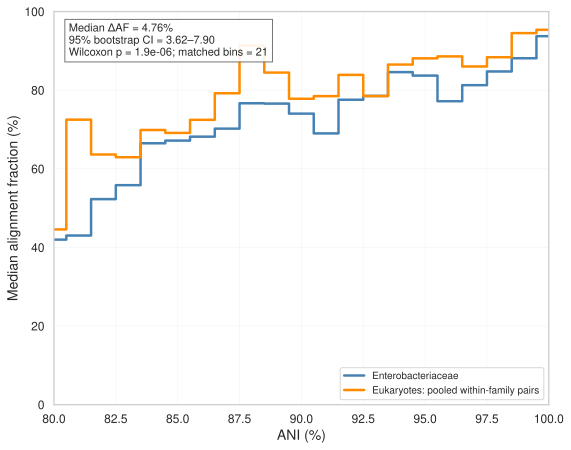

In [4]:
def stats_label(result):
    return (
        f"Median ΔAF = {result['median_delta']:.2f}%\n"
        f"95% bootstrap CI = {result['ci_low']:.2f}–{result['ci_high']:.2f}\n"
        f"Wilcoxon p = {result['p_value']:.2g}; matched bins = {result['n_bins']}"
    )


fig, ax_pooled = plt.subplots(figsize=(8, 7))
ax_pooled.step(entero_curve['ANI_bin'], entero_curve['AF_median'], where='mid', lw=2.5, color='steelblue', label='Enterobacteriaceae')
ax_pooled.step(euk_pooled_curve['ANI_bin'], euk_pooled_curve['AF_median'], where='mid', lw=2.5, color='darkorange', label='Eukaryotes: pooled within-family pairs')
ax_pooled.text(0.03, 0.97, stats_label(pooled_stats), transform=ax_pooled.transAxes, va='top', fontsize=11, bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.9))
ax_pooled.set_xlim(ANI_MIN, ANI_MAX)
ax_pooled.set_ylim(0, 100)
ax_pooled.set_xlabel('ANI (%)', fontsize=14)
ax_pooled.set_ylabel('Median alignment fraction (%)', fontsize=14)
ax_pooled.tick_params(labelsize=12)
ax_pooled.grid(True, color='#e6e6e6', linewidth=0.6, alpha=0.45)
ax_pooled.legend(loc='lower right', fontsize=10, frameon=True)
fig.subplots_adjust(left=0.12, right=0.98, top=0.90, bottom=0.12)
fig.savefig(FIGURE_SVG, bbox_inches='tight')
fig.savefig(FIGURE_PDF, bbox_inches='tight')
fig.savefig(FIGURE_PNG, dpi=300, bbox_inches='tight')
plt.close(fig)
display(SVG(filename=str(FIGURE_SVG)))